In [1]:
from ESF_gurobipy_NJC2025_Ex3_2 import parallel_calculate_sm_esf_processes, generate_design_vectors_sobol, calculate_sm_esf
from ppopt.mplp_program import MPLP_Program
from ppopt.mpmodel import MPModeler
from ppopt.mp_solvers.solve_mpqp import solve_mpqp, mpqp_algorithm
import numpy as np
from collections import defaultdict
from typing import List
from scipy.optimize import linprog
import warnings
import pickle
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
import gurobipy as gp
from gurobipy import GRB
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.compose import TransformedTargetRegressor
import itertools
from functools import reduce
import operator
import math
from gurobipy import nlfunc
from matplotlib import rc
from sklearn.model_selection import train_test_split

##############################################################################################################
# FEASIBILITY FUNCTION AND UNCERTAINTY BOUNDS
##############################################################################################################

In [2]:
def mpformulate_theta_bounds(flex_sol, num_theta: int, theta_bounds: list, num_design: int = 0, design_bounds: list = None, psi_idx: int = 0, theta_m: int = 0):
    A0, b0, F0 = np.empty((len(flex_sol), num_theta)), np.empty(
        (len(flex_sol), 1)), np.empty((len(flex_sol), num_design))
    num_cr = len(flex_sol.critical_regions)
    
    for i, region in enumerate(flex_sol.critical_regions):
        
        # print(f'num_cr:{num_cr}')
        # print(f'num_theta:{num_theta}')
        # print(f'num_design:{num_design}')
        # print(f"A0: {A0}")
        # print(f"b0: {b0}")
        # print(f"F0: {F0}")
        # print(f"A0 shape: {A0.shape}")
        # print(f"b0 shape: {b0.shape}")
        # print(f"F0 shape: {F0.shape}")
        A0[i] = region.A[psi_idx, :num_theta]
        b0[i] = -region.b[psi_idx]
        F0[i] = -region.A[psi_idx, num_theta:num_theta+num_design]

    c = np.hstack([np.array([-1, 1]).reshape(1, -1),
                  np.zeros((1, 2 * (num_theta - 1 - theta_m)))]).reshape(-1, 1)
    # print(f'c:{c}')
    # print(f'c.shape: {c.shape}')

    row1_block = np.hstack([block for i in range(theta_m, num_theta)
                           for block in (A0[:, [i]], np.zeros((num_cr, 1)))])
    row2_block = np.hstack([block for i in range(theta_m, num_theta)
                           for block in (np.zeros((num_cr, 1)), A0[:, [i]])])
    bound_row = np.hstack([np.array([-1, 1]).reshape(1, -1),
                          np.zeros((1, 2 * (num_theta - 1 - theta_m)))])
    A = np.vstack([row1_block, row2_block, bound_row, -
                  np.eye(2*(num_theta-theta_m)), np.eye(2*(num_theta-theta_m))])
    # print(f'A: {A}')
    # print(f'A.shape: {A.shape}')

    x_lb = np.array([val for i in range(theta_m, len(theta_bounds))
                    for val in [theta_bounds[i][0]] * 2])
    x_ub = np.array([val for i in range(theta_m, len(theta_bounds))
                    for val in [theta_bounds[i][1]] * 2])
    b = np.vstack([b0, b0, np.zeros((1, 1)), -
                  x_lb.reshape(-1, 1), x_ub.reshape(-1, 1)])
    # print(f'b: {b}')
    # print(f'b.shape: {b.shape}')

    if F0.size == 0 and theta_m == 0:
        # print('here')
        return A, b, c, np.array([]), np.array([]), np.array([]), np.array([])

    F = np.vstack([F0, F0, np.zeros((1, num_design)), np.zeros(
        (4*(num_theta-theta_m), num_design))]) if num_design > 0 else np.vstack([F0, F0])
    # print(f'F:{F}')
    # print(f'F.shape: {F.shape}')
    if theta_m > 0:
        F_lltheta = np.hstack([A0[:, [i]] for i in range(theta_m)])
        # print(f'F_lltheta: {F_lltheta}')
        # print(f'F_lltheta.shape: {F_lltheta.shape}')
        F = np.hstack([np.vstack([-F_lltheta, -F_lltheta, np.zeros((1, len(range(theta_m)))), np.zeros((4*(num_theta-theta_m), theta_m))]), F]
                      ) if F.size > 0 else np.vstack([-F_lltheta, -F_lltheta, np.zeros((1, len(range(theta_m)))), np.zeros((4*(num_theta-theta_m), theta_m))])
    # print(f'F:{F}')
    # print(f'F.shape: {F.shape}')

    H = np.zeros((2*(num_theta-theta_m), theta_m+num_design))
    # print(f'H:{H}')
    # print(f'H.shape: {H.shape}')

    A_t = np.vstack([-np.eye(theta_m+num_design), np.eye(theta_m+num_design)])
    # print(f'A_t:{A_t}')
    # print(f'A_t.shape: {A_t.shape}')

    theta_lb = np.array([-theta_bounds[i][0] for i in range(theta_m)] + ([-j[0] for j in design_bounds] if isinstance(design_bounds, list)
                                                                         else [])).reshape(-1, 1)
    theta_ub = np.array([theta_bounds[i][1] for i in range(theta_m)] + ([j[1] for j in design_bounds] if isinstance(design_bounds, list)
                                                                        else [])).reshape(-1, 1)

    b_t = np.vstack([theta_lb, theta_ub])
    # print(f'b_t:{b_t}')
    # print(f'b_t.shape: {b_t.shape}')

    return A, b, c, H, A_t, b_t, F

def get_theta_bounds(flex_sol, numt, tbounds, numd: int = 0, dbounds: list = None, mp_algo: mpqp_algorithm = mpqp_algorithm.combinatorial):
    theta_bound_dict = defaultdict(dict)
    prob_dict = defaultdict(dict)

    for i in range(numt):
        A, b, c, H, A_t, b_t, F = mpformulate_theta_bounds(
            flex_sol=flex_sol, num_theta=numt, num_design=numd, theta_bounds=tbounds, design_bounds=dbounds, theta_m=i)
        # print(f'A.shape:{A.shape}')
        # print(f'b.shape: {b.shape}')
        # print(f'F.shape: {F.shape}')
        if F.size != 0:
            try:
                with warnings.catch_warnings():
                    warnings.filterwarnings("error", category=UserWarning, message="The chebychev ball has either a radius of zero, or the problem is not feasible!")
                    prob = MPLP_Program(A=A, b=b, c=c, H=H, A_t=A_t, b_t=b_t, F=F)

                prob.process_constraints()
                solution = solve_mpqp(problem=prob, algorithm=mp_algo)

                prob_dict[f"t{i}"] = prob
                theta_bound_dict[f"t{i}"] = solution

            except UserWarning as w:
                # MPLP infeasible / degenerate
                print(f"[theta {i}] MPLP infeasible / zero Chebyshev ball: {w}")
                prob_dict[f"t{i}"] = None
                theta_bound_dict[f"t{i}"] = None

        else:
            # LP fallback branch via scipy.optimize.linprog
            linres = linprog(c=c, A_ub=A, b_ub=b)

            if not linres.success:
                print(f"[theta {i}] linprog failed: status={linres.status}, "f"message={linres.message}")
                prob_dict[f"t{i}"] = linres
                theta_bound_dict[f"t{i}"] = None
            else:
                prob_dict[f"t{i}"] = linres
                theta_bound_dict[f"t{i}"] = [linres.x[1], linres.x[0]]

        print(f"Finished solving for theta{i+1}")

    probs = [p for _, p in prob_dict.items()]
    sols = [sol for _, sol in theta_bound_dict.items()]
    return probs, sols


def get_bounds_regions(sols: List, min_idx: int = 1, max_idx: int = 0):
    t_bounds_list = []
    t_regions_list = []

    for theta_sol in sols:
        if theta_sol is None:
            t_bounds_list.append(None)
            t_regions_list.append(None)
            continue

        if not getattr(theta_sol, "critical_regions", None):
            t_bounds_list.append(None)
            t_regions_list.append(None)
            continue

        min_max_list = []
        region_list = []

        for cr in theta_sol.critical_regions:
            # Store bounds
            Ab = np.concatenate([cr.A, cr.b], axis=1)[:2]
            min_max_list.append([Ab[min_idx].tolist(), Ab[max_idx].tolist()])

            # Store region constraints
            Ef = np.concatenate([cr.E, -cr.f], axis=1)
            region_array = np.array([row.tolist() for row in Ef], dtype=float)
            region_list.append(region_array)

        # Append per-theta data
        t_bounds_list.append(np.array(min_max_list))
        # <-- each region is a 2D array
        t_regions_list.append(np.array(region_list, dtype=object))

    return t_bounds_list, t_regions_list

##############################################################################################################
# PREPARE STATE DATA
##############################################################################################################

In [3]:
def _prepare_state_data(state, tbounds, dbounds, *, solve_algo, theta_algo, log=False):
    """
    Build and solve the flexibility problem for one state, then return only valid theta-related data.

    Returns
    -------
    dict with keys:
        state
        flex_sol
        sol_list
        t_bounds_list
        t_regions_list
        filtered_solutions
        filtered_theta_bounds
        filtered_theta_regions
    or None if no valid theta regions exist.
    """
    state_model = create_flexibility_model(y_list=state, tbounds=tbounds, dbounds=dbounds)
    state_prob = state_model.formulate_problem()
    state_prob.process_constraints()

    flex_sol = solve_mpqp(problem=state_prob, algorithm=solve_algo)
    
    numt = len(tbounds)
    numd = len(dbounds)

    if log:
        print(
            f"Number of critical regions in for flexibility function for state {state}: {len(flex_sol.critical_regions)}")

    _, sol_list = get_theta_bounds(flex_sol=flex_sol, numt=numt, numd=numd, tbounds=tbounds, dbounds=dbounds,
                                   mp_algo=theta_algo)

    t_bounds_list, t_regions_list = get_bounds_regions(sols=sol_list)

    filtered_solutions = []
    filtered_theta_bounds = []
    filtered_theta_regions = []

    for k, (sol, tb, tr) in enumerate(zip(sol_list, t_bounds_list, t_regions_list)):
        if sol is None or tb is None or tr is None:
            # mark as empty stage but preserve position
            filtered_solutions.append(None)
            filtered_theta_bounds.append(None)
            filtered_theta_regions.append(None)
        else:
            filtered_solutions.append(sol)
            filtered_theta_bounds.append(tb)
            filtered_theta_regions.append(tr)

    return {
        "state": state,
        "flex_sol": flex_sol,
        "sol_list": sol_list,
        "theta_bounds_list": t_bounds_list,
        "theta_regions_list": t_regions_list,
        "filtered_solutions": filtered_solutions,
        "filtered_theta_bounds": filtered_theta_bounds,
        "filtered_theta_regions": filtered_theta_regions,
    }

##############################################################################################################
# CASE STUDY
##############################################################################################################

In [4]:
suppliers = ['A', 'B', 'C']
markets = ['D', 'E', 'F']
sites = ['0', '1', '2', '3']

supply_theta_nominal = {'A': 45000, 'B': 100000, 'C': 75000}
supply_theta_stddev = {'A': np.sqrt(7500), 'B': np.sqrt(16667), 'C': np.sqrt(12500)}

conv = 1/2.4 # basis is feed

demand = {'D': 0, 'E': 60000, 'F': 25000} # demand of product

no_trips = 365 # number of trips made by each truck per year, basically one round trip per day per truck

site_cap = {'0': 50000, '1': 50000, '2': 50000, '3': 75000} # capacity of each site, basis is feed

capex_factor = {'0': 5000.00001, '1': 5000.000011, '2': 5000.000012, '3': 5000.000013}

availability_factor = 0.959260199

t_bounds = [(supply_theta_nominal['A'] - 4*supply_theta_stddev['A'], supply_theta_nominal['A'] + 4*supply_theta_stddev['A']),
            (supply_theta_nominal['B'] - 4*supply_theta_stddev['B'], supply_theta_nominal['B'] + 4*supply_theta_stddev['B']),
            (supply_theta_nominal['C'] - 4*supply_theta_stddev['C'], supply_theta_nominal['C'] + 4*supply_theta_stddev['C'])]

d_bounds = [(0, 1000), (0, 1000), (0, 1000), (0, 1000)]
nt = len(t_bounds)
nd = len(d_bounds)
disruption_dict = {
    'Site 1': {
        1: 0.8,
        0.5: 0.15,
        0: 0.05
    },
    'Site 2':{
        1: 0.7,
        0.5: 0.2,
        0: 0.1
    },
    'Site 3':{
        1: 0.6,
        0.5: 0.25,
        0: 0.15
    },
    'Site 4':{
        1: 0.9,
        0.5: 0.05,
        0: 0.05
    }
}

y_dict = dict()
combo_idx = list(disruption_dict.keys())
combo_lists = [tuple(disruption_dict[c_idx].keys()) for c_idx in combo_idx]

for combo in itertools.product(*combo_lists):
    probs = [disruption_dict[c_idx][c] for c_idx, c in zip(combo_idx, combo)]
    y_dict[combo] = reduce(operator.mul, probs, 1)

case_study = 'NJC2025_Ex3_2'
quad_method = 'smolyak'
smolyak_level = 16

feasibility_algo = mpqp_algorithm.geometric
theta_bounds_algo = mpqp_algorithm.geometric

feas_algo_name = 'gp' if feasibility_algo.name in ['geometric_parallel', 'geometric'] else ('cb' if feasibility_algo in ['combinatorial', 'combinatorial_parallel'] else '')
tb_algo_name = 'gp' if theta_bounds_algo.name in ['geometric_parallel', 'geometric'] else ('cb' if theta_bounds_algo in ['combinatorial', 'combinatorial_parallel'] else '')

def create_flexibility_model(tbounds:list, dbounds:list, y_list: tuple = None):
    m = MPModeler()
    # print(f'y_list: {y_list}')
    
    u = m.add_var(name='u')
    product = {si: m.add_var(name=f'product[{si}]') for si in sites}
    feed = {si: m.add_var(f'feed[{si}]') for si in sites}
    feed_ship = {(su, si): m.add_var(name=f'feed_ship[{su},{si}]') for su, si in itertools.product(suppliers, sites)}
    product_ship = {(si, ma): m.add_var(name=f'product_ship[{si},{m}]') for si, ma in itertools.product(sites, markets)}
    capex = m.add_var(name='capex')
    
    supply_theta = {su: m.add_param(name=f'supply_theta[{su}]') for su in suppliers}
    trans_cap = {si: m.add_param(name=f'trans_cap[{si}]') for si in sites}
    
    m.add_constrs(sum(feed_ship[su, si] for su in suppliers) == feed[si] for si in sites)
    m.add_constr(capex == sum(capex_factor[si]*trans_cap[si] for si in sites))
    m.add_constrs(product[si] == feed[si]*conv for si in sites)
    m.add_constrs(sum(product_ship[si, ma] for ma in markets) == product[si] for si in sites)
    
    m.add_constrs(sum(feed_ship[su, si] for si in sites) <= supply_theta[su] + u for su in suppliers)
    m.add_constrs(feed[si] <= site_cap[si] * availability_factor + u for si in sites)
    m.add_constrs(demand[ma] <= sum(product_ship[si, ma] for si in sites) + u for ma in markets)
    m.add_constrs(feed[si] + product[si] <= trans_cap[si]*no_trips*y_list[int(si)] + u for si in sites)
    
    m.add_constrs(supply_theta[su] >= tbounds[su_idx][0] for su_idx, su in enumerate(suppliers))
    m.add_constrs(supply_theta[su] <= tbounds[su_idx][1] for su_idx, su in enumerate(suppliers))
    m.add_constrs(trans_cap[si] >= dbounds[si_idx][0] for si_idx, si in enumerate(sites))
    m.add_constrs(trans_cap[si] <= dbounds[si_idx][1] for si_idx, si in enumerate(sites))
    
    m.set_objective(u)
    
    return m

def joint_pdf(theta: list, eps:float = 1e-8):
    theta_a, theta_b, theta_c = theta
    a_nom, b_nom, c_nom = supply_theta_nominal['A'], supply_theta_nominal['B'], supply_theta_nominal['C']
    a_std, b_std, c_std = supply_theta_stddev['A'], supply_theta_stddev['B'], supply_theta_stddev['C']
    
    contrib_a = (1/np.sqrt(2*np.pi)) * (1/a_std) * np.exp(-(theta_a - a_nom)**2/(2 * a_std**2))
    contrib_b = (1/np.sqrt(2*np.pi)) * (1/b_std) * np.exp(-(theta_b - b_nom)**2/(2 * b_std**2))
    contrib_c = (1/np.sqrt(2*np.pi)) * (1/c_std) * np.exp(-(theta_c - c_nom)**2/(2 * c_std**2))
      
    return contrib_a * contrib_b * contrib_c

def pdf_builder(theta, n, eps=1e-8):
    theta_a = theta[(0, n)]
    theta_b = theta[(1, n)]
    theta_c = theta[(2, n)]
    
    a_nom, b_nom, c_nom = supply_theta_nominal['A'], supply_theta_nominal['B'], supply_theta_nominal['C']
    a_std, b_std, c_std = supply_theta_stddev['A'], supply_theta_stddev['B'], supply_theta_stddev['C']
    
    contrib_a = (1/np.sqrt(2*math.pi)) * (1/a_std) * nlfunc.exp(-((theta_a - a_nom) * (theta_a - a_nom))/(2 * a_std * a_std))
    contrib_b = (1/np.sqrt(2*math.pi)) * (1/b_std) * nlfunc.exp(-((theta_b - b_nom) * (theta_b - b_nom))/(2 * b_std * b_std))
    contrib_c = (1/np.sqrt(2*math.pi)) * (1/c_std) * nlfunc.exp(-((theta_c - c_nom) * (theta_c - c_nom))/(2 * c_std * c_std))
     
    return contrib_a * contrib_b * contrib_c

cost_coeff_list = [v for k,v in capex_factor.items()]
def cost_function(d):
    coeffs = np.array(cost_coeff_list)
    return float(np.dot(coeffs, d))

In [5]:
t_bounds

[(44653.58983848622, 45346.41016151378),
 (99483.5970565537, 100516.4029434463),
 (74552.78640450005, 75447.21359549995)]

In [6]:
# prepared_data_by_state = {
#     state: _prepare_state_data(
#         state,
#         tbounds=t_bounds,
#         dbounds=d_bounds,
#         solve_algo=feasibility_algo,
#         theta_algo=theta_bounds_algo,
#     )
#     for state in y_dict
# }
# 
# # load_prepared_data_by_state = prepared_data_by_state

In [7]:
# with open(f'state_data_{case_study}.pkl', 'wb') as f:
#     pickle.dump(prepared_data_by_state, f)

In [8]:
with open(f'state_data_{case_study}.pkl', 'rb') as f:
    load_prepared_data_by_state = pickle.load(f)

In [9]:
load_prepared_data_by_state[1,1,1,1].keys()

dict_keys(['state', 'flex_sol', 'sol_list', 'theta_bounds_list', 'theta_regions_list', 'filtered_solutions', 'filtered_theta_bounds', 'filtered_theta_regions'])

In [10]:
len(load_prepared_data_by_state[1,1,1,1]['flex_sol'])

16

In [11]:
load_prepared_data_by_state[1,1,1,1]['flex_sol'].critical_regions[0].A[0]

array([ 0.00000000e+00,  1.40269892e-16,  1.29182609e-16, -1.54678198e-17,
       -1.54678198e-17, -1.54678198e-17, -1.54678198e-17])

In [12]:
load_prepared_data_by_state[1,1,1,1]['flex_sol'].critical_regions[0].E

array([[ 0.00000000e+00, -8.00265892e-19, -6.65156210e-19,
        -1.00000000e+00, -4.72248083e-20, -4.72248083e-20,
        -4.72248083e-20],
       [ 0.00000000e+00,  8.94194102e-19,  7.34383018e-19,
        -6.07032225e-16, -1.00000000e+00, -6.07032225e-16,
        -6.07032225e-16],
       [ 0.00000000e+00,  5.88723360e-19,  8.79054498e-19,
         5.18758714e-16,  5.18758714e-16, -1.00000000e+00,
         5.18758714e-16],
       [ 0.00000000e+00,  7.56435279e-19,  1.00019998e-18,
         8.80007863e-17,  8.80007863e-17,  8.80007863e-17,
        -1.00000000e+00],
       [-1.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00],
       [ 0.00000000e+00, -1.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00, -1.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.0000000

In [13]:
load_prepared_data_by_state[1,1,1,1]['flex_sol'].critical_regions[0].f

array([[  -184.95167504],
       [  -184.95167504],
       [  -184.95167504],
       [  -278.03057562],
       [-44653.58983849],
       [-99483.59705655],
       [-74552.7864045 ],
       [ 45346.41016151],
       [100516.40294345],
       [ 75447.2135955 ],
       [  1000.        ],
       [  1000.        ],
       [  1000.        ],
       [  1000.        ]])

In [14]:
for idx, cr in enumerate(load_prepared_data_by_state[1,1,1,1]['flex_sol'].critical_regions):
    print(idx, cr.A[0], cr.b[0])

0 [ 0.00000000e+00  1.40269892e-16  1.29182609e-16 -1.54678198e-17
 -1.54678198e-17 -1.54678198e-17 -1.54678198e-17] [-1056.56649777]
1 [ 0.00000000e+00  5.15979524e-17  2.05921852e-16 -2.36245955e+01
 -1.66024789e-16 -1.66024789e-16 -1.66024789e-16] [3312.84200634]
2 [ 0.00000000e+00  5.23964834e-16 -9.80181863e-17 -1.29842481e-15
 -2.36245955e+01 -1.29842481e-15 -1.29842481e-15] [3312.84200634]
3 [ 0.00000000e+00  1.60438443e-16  1.97122871e-16 -1.93446435e-16
 -1.93446435e-16 -2.36245955e+01 -1.93446435e-16] [3312.84200634]
4 [ 0.00000000e+00  4.26748860e-16 -2.74010171e-16 -6.61410425e-16
 -6.61410425e-16 -6.61410425e-16 -2.36245955e+01] [5511.79337945]
5 [ 0.00000000e+00  5.26936670e-16 -1.25086523e-15 -2.42793792e+01
 -2.42793792e+01  1.49797546e-15  1.49797546e-15] [7924.45719027]
6 [ 0.00000000e+00 -1.76177178e-16  1.78037827e-16 -2.42793792e+01
 -3.24463165e-16 -2.42793792e+01 -3.24463165e-16] [7924.45719027]
7 [ 0.00000000e+00 -4.94147215e-16 -3.04232663e-16 -2.42793792e+01
 

In [15]:
len(load_prepared_data_by_state[1,1,1,1]['sol_list'][2].critical_regions)

1

In [16]:
load_prepared_data_by_state[1,1,1,1]['sol_list'][0].critical_regions[0]

Critical region with active set [2, 3, 4, 5, 6, 7]
The Omega Constraint indices are [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33]
The Lagrange multipliers Constraint indices are []
The Regular Constraint indices are [[], []]
  x(θ) = Aθ + b 
 λ(θ) = Cθ + d 
  Eθ <= f
 A = [[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]] 
 b = [[45346.41016151]
 [44653.58983849]
 [99483.59705655]
 [99483.59705655]
 [74552.7864045 ]
 [74552.7864045 ]] 
 C = [[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]] 
 d = [[1.]
 [0.]
 [0.]
 [0.]
 [0.]
 [1.]] 
 E = [[ 1.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  1.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  1.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]
 [-1.00000000e+00 -7.02762

In [17]:
load_prepared_data_by_state[1,1,1,1]['sol_list'][0].critical_regions[0].A[0:2]

array([[0., 0., 0., 0.],
       [0., 0., 0., 0.]])

In [18]:
load_prepared_data_by_state[1,1,1,1]['sol_list'][0].critical_regions[0].b[0:2]

array([[45346.41016151],
       [44653.58983849]])

In [19]:
1/np.sqrt(2)

0.7071067811865475

In [20]:
load_prepared_data_by_state[1,1,1,1]['sol_list'][0].critical_regions[0].E

array([[ 1.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00],
       [ 0.00000000e+00,  1.00000000e+00,  0.00000000e+00,
         0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  1.00000000e+00,
         0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         1.00000000e+00],
       [-1.00000000e+00, -7.02762463e-18, -7.02762463e-18,
        -7.02762463e-18],
       [-5.49607214e-17, -1.00000000e+00, -5.49607214e-17,
        -5.49607214e-17],
       [-8.18834909e-18, -8.18834909e-18, -1.00000000e+00,
        -8.18834909e-18],
       [-2.79966879e-17, -2.79966879e-17, -2.79966879e-17,
        -1.00000000e+00],
       [-7.07106781e-01, -7.07106781e-01,  4.36266758e-17,
         4.36266758e-17],
       [-7.07106781e-01, -9.44958694e-18, -7.07106781e-01,
        -9.44958694e-18],
       [-7.07106781e-01,  1.49223728e-15,  1.49223728e-15,
        -7.07106781e-01],
       [ 2.08909217e-17, -7.07106781e-01, -7.07106781e-01,
      

In [21]:
load_prepared_data_by_state[1,1,1,1]['sol_list'][0].critical_regions[0].f

array([[1000.        ],
       [1000.        ],
       [1000.        ],
       [1000.        ],
       [-140.2285178 ],
       [-140.2285178 ],
       [-140.2285178 ],
       [-233.30741839],
       [-230.78997944],
       [-230.78997944],
       [-296.60670123],
       [-230.78997944],
       [-296.60670123],
       [-296.60670123],
       [-295.91748574],
       [-349.65661405],
       [-349.65661405],
       [-349.65661405],
       [-395.89041096]])

##############################################################################################################
# SANITY CHECK
##############################################################################################################

In [22]:
# design_list = [1000, 1000, 1000, 1000]

In [23]:
# design_vector = np.array(design_list)

In [24]:
# esf_sm, sf_by_state_sm = calculate_sm_esf(y_d=y_dict, prepared_data_by_s=load_prepared_data_by_state, d_v=design_vector, s_level=smolyak_level)

In [25]:
# esf_sm

In [26]:
# sf_by_state_sm

##############################################################################################################
# SAMPLING
##############################################################################################################

In [27]:
ns=1024*8

In [28]:
ns

8192

In [29]:
dvector_list_sobol = generate_design_vectors_sobol(d_bounds, n_samples=ns)

In [30]:
# results = parallel_calculate_sm_esf_processes(
#     design_vectors=dvector_list_sobol,
#     y_d=y_dict,
#     load_prepared_data_by_s=load_prepared_data_by_state,
#     s_level=smolyak_level,
#     show_progress=True,
#     # cost_func=cost_function,
#     # joint_func=joint_pdf,
# )

In [31]:
# with open(f'MC_results_{case_study}_{quad_method}_{smolyak_level}_{ns}_sobol.pkl', 'wb') as f:
#     pickle.dump(results, f)

In [32]:
with open(f'MC_results_{case_study}_{quad_method}_{smolyak_level}_{ns}_sobol.pkl', 'rb') as f:
    load_results = pickle.load(f)

In [33]:
load_results[0]

{'design_vector': array([455.64988349, 112.78921179, 541.19580332, 108.55795164]),
 'cost': 6090964.251197875,
 'esf_sm': 0.0}

##############################################################################################################
# OPTIMAL SIMULATION RESULTS
##############################################################################################################

In [34]:
esf_target_list = list(np.arange(0.0,1,0.05))

In [35]:
def select_best_design(results, esf_target):
    """
    Select the best design such that:
    1. esf_sm >= esf_target
    2. minimum overshoot above esf_target
    3. tie-breaker: minimum cost
    """
    feasible = [r for r in results if r["esf_sm"] >= esf_target]

    if not feasible:
        return None

    return min(
        feasible,
        key=lambda r: (r["esf_sm"] - esf_target, r["cost"])
    )

In [36]:
sim_esf_list, sim_cost_list, sim_design_list = list(), list(), list()
for esf in esf_target_list:
    best_result = select_best_design(load_results, esf)
    if best_result is not None:
        sim_esf_list.append(best_result['esf_sm'])
        sim_cost_list.append(best_result['cost'])
        sim_design_list.append(best_result['design_vector'])

In [37]:
sim_design_list

[array([ 43.48305985, 115.50806183,  46.58532888,   7.42615946]),
 array([184.05533675, 253.48970667, 190.86771458, 258.73146672]),
 array([184.05533675, 253.48970667, 190.86771458, 258.73146672]),
 array([184.05533675, 253.48970667, 190.86771458, 258.73146672]),
 array([184.05533675, 253.48970667, 190.86771458, 258.73146672]),
 array([184.05533675, 253.48970667, 190.86771458, 258.73146672]),
 array([184.05533675, 253.48970667, 190.86771458, 258.73146672]),
 array([311.87715661, 261.73456572, 184.05084684, 309.73312631]),
 array([221.24941833, 320.75282559, 197.72012811, 564.5303363 ]),
 array([271.68377023, 156.15072567, 342.38998406, 559.93020255]),
 array([321.05422765, 207.04785455, 335.56575049, 366.92256574]),
 array([217.41869207, 368.57883073, 374.09193441, 264.42925446]),
 array([294.19350997, 348.95461798, 303.16905025, 731.11743387]),
 array([347.66419232, 384.95888188, 377.66703684, 340.01740441])]

In [38]:
sim_esf_list

[0.0,
 0.30260169367559936,
 0.30260169367559936,
 0.30260169367559936,
 0.30260169367559936,
 0.30260169367559936,
 0.30260169367559936,
 0.35933951123977426,
 0.41067372713117056,
 0.4525016067463824,
 0.5090643075896801,
 0.5511673706234131,
 0.603652353537716,
 0.6545112526153031]

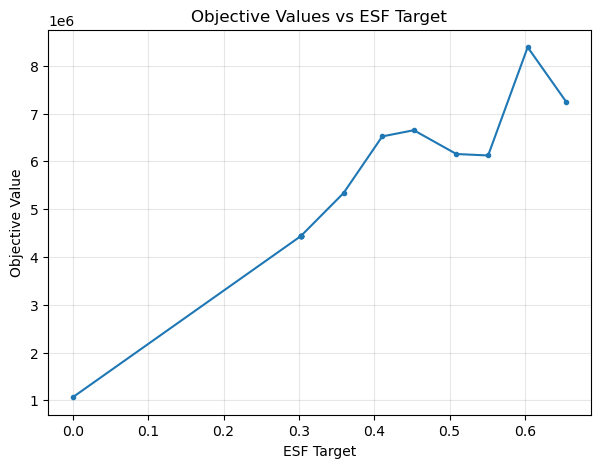

In [39]:
plt.figure(figsize=(7,5))
plt.plot(sim_esf_list, sim_cost_list, marker="o", ms=3)
plt.xlabel("ESF Target")
plt.ylabel("Objective Value")
# plt.xscale("log")
# plt.yscale("log")   # optional but often useful
plt.grid(True, alpha=0.3)
plt.title("Objective Values vs ESF Target")
plt.show()

##############################################################################################################
# REGRESSION
##############################################################################################################

In [40]:
def build_regression_dataset(results):
    X = np.vstack([r["design_vector"] for r in results])
    y = np.array([r["esf_sm"] for r in results])
    return X, y

def fit_polynomial_esf_model_zero_intercept(results, degree=2):
    """
    Polynomial regression with intercept forced to zero:
    esf_sm ≈ sum_j coef_j * feature_j, no constant term.
    """

    X, y = build_regression_dataset(results)

    model = Pipeline([
        ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
        ("linreg", LinearRegression(fit_intercept=False)),
    ])

    model.fit(X, y)
    return model

# def fit_polynomial_esf_model_zero_intercept(results, degree=2, test_size=0.2, random_state=42):
#     """
#     Polynomial regression with intercept forced to zero:
#     esf_sm ≈ sum_j coef_j * feature_j, no constant term.
#     """
# 
#     X, y = build_regression_dataset(results)
# 
#     # 1) split into train and test
#     X_train, X_test, y_train, y_test = train_test_split(
#         X, y,
#         test_size=test_size,
#         random_state=random_state,
#     )
# 
#     # 2) build the pipeline
#     model = Pipeline([
#         ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
#         ("linreg", LinearRegression(fit_intercept=False)),
#     ])
# 
#     # 3) fit on the training data only
#     model.fit(X_train, y_train)
# 
#     # 4) evaluate on the held‑out test set (optional, but recommended)
#     test_score = model.score(X_test, y_test)  # R² for regression
# 
#     return model, (X_train, X_test, y_train, y_test, test_score)

def fit_exponential_esf_model(results, degree=1, tol=1e-6):
    X = np.vstack([r["design_vector"] for r in results])
    y = np.array([r["esf_sm"]+tol for r in results])

    if np.any(y <= 0):
        raise ValueError("Need y > 0 for log-transform exponential model.")

    base_model = Pipeline([
        ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
        ("linreg", LinearRegression(fit_intercept=False))
    ])

    model = TransformedTargetRegressor(
        regressor=base_model,
        func=np.log,
        inverse_func=np.exp,
    )

    model.fit(X, y)
    return model

In [41]:
def feature_to_expr(name, d_vars):
    """
    Convert a PolynomialFeatures feature name to a Gurobi expression
    in variables d_vars (tupledict or list of decision variables).
    Supports feature names like: 'x0', 'x1^2', 'x0 x1', 'x0^2 x2', etc.
    """
    # Single variable, maybe with power
    if "^" in name and " " not in name:
        base, pow_str = name.split("^")
        idx = int(base[1:])  # 'x0' -> 0
        power = int(pow_str)
        expr = d_vars[idx]
        for _ in range(power - 1):
            expr = expr * d_vars[idx]  # quadratic or higher
        return expr

    # Product of different variables, maybe repeated: 'x0 x1', 'x0^2 x2', etc.
    parts = name.split(" ")
    expr = 1.0
    for p in parts:
        if "^" in p:
            base, pow_str = p.split("^")
            idx = int(base[1:])
            power = int(pow_str)
            term = d_vars[idx]
            for _ in range(power - 1):
                term = term * d_vars[idx]
        else:
            idx = int(p[1:])
            term = d_vars[idx]
        expr = expr * term
    return expr

In [42]:
def plot_actual_vs_predicted_poly(model, X, y, title_prefix="Polynomial regression"):
    # Predictions
    y_pred = model.predict(X)

    # Metrics (optional but useful)
    r2 = r2_score(y, y_pred)
    rmse = mean_squared_error(y, y_pred)
    
    rc('font', **{'family': 'serif', 'serif': ['Computer Modern'], 'size': 12})
    rc('text', usetex=False)
    
    plt.figure(figsize=(6, 6))
    plt.scatter(y, y_pred, alpha=0.5, edgecolor="k")
    plt.xlabel("Actual CFRI Value (Quadrature)")
    plt.ylabel("Predicted CFRI Value (Regression)")

    title = f"{title_prefix}\nR²={r2:.3f}, RMSE={rmse:.3e}"
    plt.title(title)

    # 45-degree line
    min_v = min(y.min(), y_pred.min())
    max_v = max(y.max(), y_pred.max())
    plt.plot([min_v, max_v], [min_v, max_v], "r--", linewidth=2)

    plt.axis("equal")
    plt.tight_layout()
    plt.grid(alpha=0.6)
    plt.rcdefaults()
    # plt.savefig('Actual vs Predicted ESF')
    plt.show()


# 
# # ax.plot(range(start, end), list(value for key, value in ph30_cl_load_results.output['S'].items() if key[0]=='loc5' and key[1]=='com1_sold')[start:end], label='with learning (ph 30)', color='green', linestyle='-', linewidth='2.5')
# 
# # Customize the plot
# ax.set_xlabel('Time Horizon')
# ax.set_ylabel('Fulfilled Demand')
# # ax.set_title('FIX TITLE')
# ax.legend()
# ax.plot(linewidth=0.5)
# ax.set_xticks(range(start, end, 2))
# plt.grid(alpha=0.6)
# plt.rcdefaults()
# # plt.savefig(fname = 'cl_ncl_compare', dpi = 300)
# # Show the plot
# plt.show()

In [43]:
def plot_regression_diagnostics(
    model,
    X,
    y,
    title_prefix="Regression model",
    figsize=(12, 5),
    point_alpha=0.35,
    point_size=30,
):
    """
    Plot:
      1) Actual vs predicted
      2) Residuals vs predicted

    Works for any fitted model with model.predict(X).
    """
    y = np.asarray(y)
    y_pred = np.asarray(model.predict(X))
    residuals = y - y_pred

    r2 = r2_score(y, y_pred)
    rmse = mean_squared_error(y, y_pred)

    fig, axes = plt.subplots(1, 2, figsize=figsize)

    # ---- Left: Actual vs predicted ----
    ax = axes[0]
    ax.scatter(
        y,
        y_pred,
        alpha=point_alpha,
        s=point_size,
        edgecolors="white",
        linewidths=0.3,
    )

    min_v = min(np.min(y), np.min(y_pred))
    max_v = max(np.max(y), np.max(y_pred))
    ax.plot([min_v, max_v], [min_v, max_v], "r--", linewidth=2)

    ax.set_xlabel("Actual esf_sm")
    ax.set_ylabel("Predicted esf_sm")
    ax.set_title(f"{title_prefix}\nR²={r2:.3f}, RMSE={rmse:.3e}")
    ax.grid(alpha=0.2)

    # Optional: keep same scales visually
    ax.set_xlim(min_v, max_v)
    ax.set_ylim(min_v, max_v)

    # ---- Right: Residuals vs predicted ----
    ax = axes[1]
    ax.scatter(
        y_pred,
        residuals,
        alpha=point_alpha,
        s=point_size,
        edgecolors="white",
        linewidths=0.3,
    )
    ax.axhline(0.0, color="r", linestyle="--", linewidth=2)

    ax.set_xlabel("Predicted esf_sm")
    ax.set_ylabel("Residual (actual - predicted)")
    ax.set_title("Residuals vs predicted")
    ax.grid(alpha=0.2)

    plt.tight_layout()
    plt.show()

In [44]:
reg_degree = 3

In [45]:
poly_model = fit_polynomial_esf_model_zero_intercept(load_results, degree=reg_degree)

poly = poly_model.named_steps["poly"]
lin = poly_model.named_steps["linreg"]

print("Intercept:", lin.intercept_)     # should be 0.0 (or very close numerically)
print("Num features:", len(poly.get_feature_names_out()))

Intercept: 0.0
Num features: 34


In [46]:
# poly_results[-1]

In [47]:
feature_names = poly.get_feature_names_out()
coefs = lin.coef_  # no intercept

In [48]:
feature_names

array(['x0', 'x1', 'x2', 'x3', 'x0^2', 'x0 x1', 'x0 x2', 'x0 x3', 'x1^2',
       'x1 x2', 'x1 x3', 'x2^2', 'x2 x3', 'x3^2', 'x0^3', 'x0^2 x1',
       'x0^2 x2', 'x0^2 x3', 'x0 x1^2', 'x0 x1 x2', 'x0 x1 x3', 'x0 x2^2',
       'x0 x2 x3', 'x0 x3^2', 'x1^3', 'x1^2 x2', 'x1^2 x3', 'x1 x2^2',
       'x1 x2 x3', 'x1 x3^2', 'x2^3', 'x2^2 x3', 'x2 x3^2', 'x3^3'],
      dtype=object)

In [49]:
X, y = build_regression_dataset(load_results)

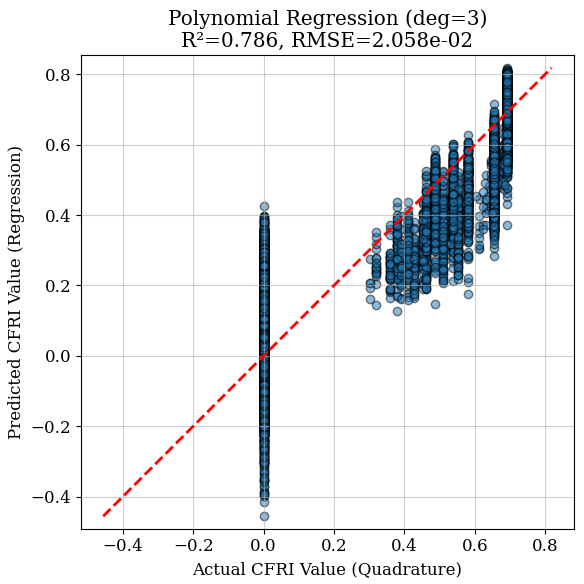

In [50]:
plot_actual_vs_predicted_poly(poly_model, X, y, title_prefix=f"Polynomial Regression (deg={reg_degree})")

##############################################################################################################
# GUROBI MODEL
##############################################################################################################

In [51]:
def build_base_gurobi_model(dbounds, features, coeffs, intercept=0.0, cost_builder=None, esf_target_init=0.0):
    m = gp.Model("ESF_design")

    d = m.addVars(
        len(d_bounds),
        lb=[b[0] for b in dbounds],
        ub=[b[1] for b in dbounds],
        name="d"
    )

    ESF = m.addVar(lb=0, name="ESF")
    Cost = m.addVar(lb=0, name="Cost")
    
    if cost_builder is None:
        cost_expr = gp.quicksum(d[j] for j in d.keys())
    else:
        cost_expr = gp.quicksum(cost_builder[j]*d[j]*365 for j in d.keys())
        
    m.addConstr(Cost == cost_expr, name='cost_expr')
    
    m.addConstr(ESF >= esf_target_init, name="esf_target_con")
    
    m.setObjective(Cost, GRB.MINIMIZE)
    
    m._esf_expr = intercept
    # m.update()
    for name, coef in zip(features, coeffs):
        if abs(coef) < 1e-12:
            continue
        m._esf_expr += coef * feature_to_expr(name, d)  # d are your Gurobi vars
        # print(esf_expr)
    
    m.addConstr(ESF == m._esf_expr, name="esf_expr")
    
    m.update()
    
    return m

In [52]:
grb_model = build_base_gurobi_model(dbounds=d_bounds, cost_builder=cost_coeff_list, features=feature_names, coeffs=coefs, intercept=lin.intercept_)

Set parameter Username
Academic license - for non-commercial use only - expires 2027-02-12


In [53]:
esf_expr = grb_model._esf_expr
esf_expr

<gurobi.NLExpr: 0.00025733572558385106 * d[0] + 0.00014154079342233193 * d[1] + 2.583607925813159e-05 * d[2] + -0.0005344265500528637 * d[3] + -2.318663436809277e-06 * d[0]**2 + 1.5712783302551545e-06 * d[0] * d[1] + 1.6184709401164171e-06 * d[0] * d[2] + 2.21414797151165e-06 * d[0] * d[3] + -2.0590733869726697e-06 * d[1]**2 + 1.713533437209607e-06 * d[1] * d[2] + 2.242209218564894e-06 * d[1] * d[3] + -1.833342149116894e-06 * d[2]**2 + 2.369343170478469e-06 * d[2] * d[3] + -6.062432757519869e-07 * d[3]**2 + 1.9411439391285333e-09 * d[0]**2 * d[0] + -8.699178656047555e-10 * d[0]**2 * d[1] + -8.967762356298849e-10 * d[0]**2 * d[2] + -1.298025982199358e-09 * d[0]**2 * d[3] + -8.457029865154247e-10 * d[1]**2 * d[0] + 3.808810622320894e-10 * d[0] * d[1] * d[2] + 4.6067959026983597e-10 * d[0] * d[1] * d[3] + -8.689832270335526e-10 * d[2]**2 * d[0] + 4.895376790360808e-10 * d[0] * d[2] * d[3] + -9.876081865162284e-10 * d[3]**2 * d[0] + 1.7712421774051886e-09 * d[1]**2 * d[1] + -9.491101058928

In [54]:
trade_off_dict = {}
for eps in esf_target_list:
    
    esf_target_con = grb_model.getConstrByName('esf_target_con')
    esf_target_con.RHS = eps
    
    grb_model.optimize()
    
    if grb_model.Status == GRB.OPTIMAL:
    
        d_list = list()
        for j in range(len(d_bounds)):
            temp_var = grb_model.getVarByName(f'd[{j}]')
            d_list.append(temp_var.X)
        
        ESF_var = grb_model.getVarByName('ESF')
        
        trade_off_dict[eps] = {
            'design': np.array(d_list),
            'cost': grb_model.ObjVal,
            'ESF': ESF_var.X
        }

Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: 13th Gen Intel(R) Core(TM) i7-13700, instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 24 logical processors, using up to 24 threads

Optimize a model with 2 rows, 6 columns and 6 nonzeros
Model fingerprint: 0x208e2041
Model has 1 general nonlinear constraint (50 nonlinear terms)
Variable types: 6 continuous, 0 integer (0 binary)
Coefficient statistics:
  Matrix range     [1e+00, 2e+06]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e+03, 1e+03]
  RHS range        [0e+00, 0e+00]
Found heuristic solution: objective 0.0000000

Explored 0 nodes (0 simplex iterations) in 0.01 seconds (0.00 work units)
Thread count was 1 (of 24 available processors)

Solution count 1: 0 

Optimal solution found (tolerance 1.00e-04)
Best objective 0.000000000000e+00, best bound 0.000000000000e+00, gap 0.0000%
Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (win64 - Windows 11+.0 (26200.2))



In [55]:
trade_off_dict

{0.0: {'design': array([0., 0., 0., 0.]), 'cost': 0.0, 'ESF': 0.0},
 0.05: {'design': array([137.60879629, 128.74305249, 117.01140363,  67.63314733]),
  'cost': 823068431.3488325,
  'ESF': 0.05},
 0.1: {'design': array([179.24527726, 173.93549246, 167.42145009, 151.47567542]),
  'cost': 1226542161.6021214,
  'ESF': 0.1},
 0.15000000000000002: {'design': array([209.23452924, 206.80285673, 204.58290838, 212.2232728 ]),
  'cost': 1519939513.5334635,
  'ESF': 0.15},
 0.2: {'design': array([235.19393894, 235.60266458, 235.82957975, 263.81812684]),
  'cost': 1771060870.044608,
  'ESF': 0.2},
 0.25: {'design': array([259.06610485, 261.95771773, 264.05314324, 310.53428669]),
  'cost': 1999490540.4541583,
  'ESF': 0.25},
 0.30000000000000004: {'design': array([281.36770022, 286.303943  , 291.47912121, 354.23689397]),
  'cost': 2214432481.720454,
  'ESF': 0.3},
 0.35000000000000003: {'design': array([303.28286779, 310.81419948, 317.42290564, 395.25967107]),
  'cost': 2421372855.8971777,
  'ESF':

In [56]:
# dvector_list_opt = [eps_dict['design'] for eps, eps_dict in trade_off_dict.items()]
# 
# final_results = parallel_calculate_sm_esf_processes(
#     design_vectors=dvector_list_opt,
#     y_d=y_dict,
#     load_prepared_data_by_s=load_prepared_data_by_state,
#     s_level=smolyak_level,
#     show_progress=True,
#     # cost_func=cost_function,
#     # joint_func=joint_pdf,
# )

In [57]:
# final_results

In [58]:
# for eps, eps_dict in trade_off_dict.items():
#     esf_eps_sm, _ = calculate_sm_esf(y_d=y_dict, prepared_data_by_s=load_prepared_data_by_state, d_v=eps_dict['design'], s_level=smolyak_level)
#     eps_dict['ESF_actual'] = esf_eps_sm

In [59]:
# # Customize the plot
# ax.set_xlabel('Time Horizon')
# ax.set_ylabel('Fulfilled Demand')
# # ax.set_title('FIX TITLE')
# ax.legend()
# ax.plot(linewidth=0.5)
# ax.set_xticks(range(start, end, 2))
# plt.grid(alpha=0.6)
# plt.rcdefaults()
# # plt.savefig(fname = 'cl_ncl_compare', dpi = 300)
# # Show the plot
# plt.show()

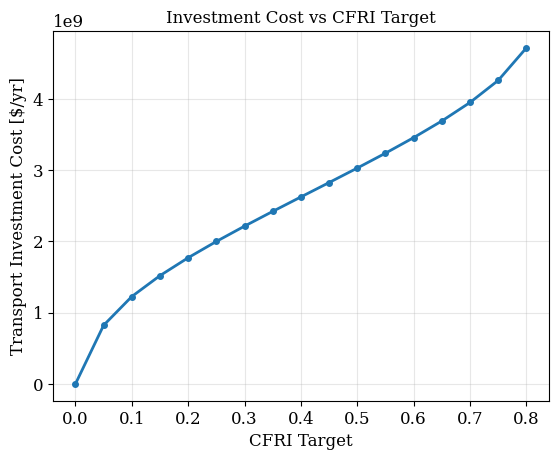

In [60]:
rc('font', **{'family': 'serif', 'serif': ['Computer Modern'], 'size': 12})
rc('text', usetex=False)
fig, ax = plt.subplots()

trade_off_esf_list = list(trade_off_dict.keys())
trade_off_cost_list = [v['cost'] for k,v in trade_off_dict.items()]
# trade_off_esf_opt_list = [v['esf_sm'] for v in final_results]

ax.plot(trade_off_esf_list, trade_off_cost_list, marker="o", ms=4, linestyle='-', linewidth='2')

ax.set_xlabel("CFRI Target")
ax.set_ylabel("Transport Investment Cost [$/yr]")

plt.grid(True, alpha=0.3)
plt.rcdefaults()
plt.title("Investment Cost vs CFRI Target")
# plt.savefig("NJC2025_Ex3_2_tradeoff_all.png")
plt.show()

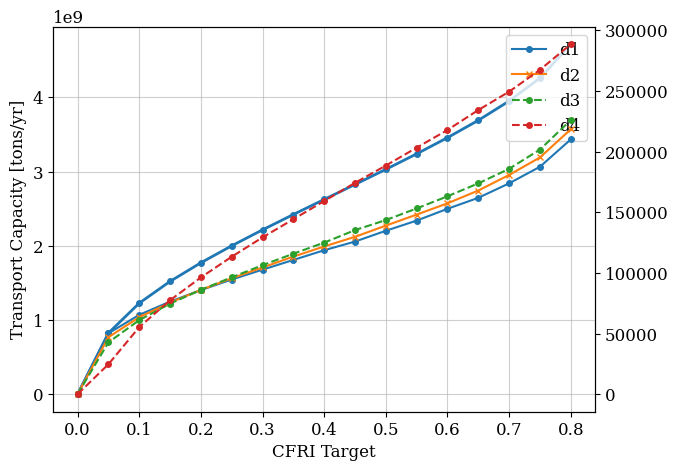

In [61]:
rc('font', **{'family': 'serif', 'serif': ['Computer Modern'], 'size': 12})
rc('text', usetex=False)
fig, ax = plt.subplots(figsize=(7,5))

trade_off_esf_list = list(trade_off_dict.keys())
trade_off_cost_list = [v['cost'] for k,v in trade_off_dict.items()]
# trade_off_esf_opt_list = [v['esf_sm'] for v in final_results]

ax.plot(trade_off_esf_list, trade_off_cost_list, marker="o", ms=4, linestyle='-', linewidth='2')

ax.set_xlabel("CFRI Target")
ax.set_ylabel("Transport Investment Cost [$/yr]")

ax2 = ax.twinx() 

trade_off_esf_list = list(trade_off_dict.keys())
d1_list = [v['design'][0] * 365 for k,v in trade_off_dict.items()]
d2_list = [v['design'][1] * 365 for k,v in trade_off_dict.items()]
d3_list = [v['design'][2] * 365 for k,v in trade_off_dict.items()]
d4_list = [v['design'][3] * 365 for k,v in trade_off_dict.items()]

# plt.figure(figsize=(7,5))
ax2.plot(trade_off_esf_list, d1_list, marker="o", ms=4, label='d1', linestyle='-')
ax2.plot(trade_off_esf_list, d2_list, marker="x", ms=4, label='d2', linestyle='-')
ax2.plot(trade_off_esf_list, d3_list, marker="o", ms=4, label='d3', linestyle='--')
ax2.plot(trade_off_esf_list, d4_list, marker="o", ms=4, label='d4', linestyle='--')

# --- legend combining both axes ---
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper right')  # [web:29]

ax.set_xlabel("CFRI Target")
ax.set_ylabel("Transport Capacity [tons/yr]")

ax.grid(alpha=0.6)
plt.rcdefaults()
# plt.savefig('Revised design under UU.png')
plt.show()

In [62]:
# plt.figure(figsize=(7,5))
# 
# # Two curves
# plt.plot(trade_off_esf_list,     trade_off_cost_list, marker="o", ms=3, label="Regression")
# plt.plot(trade_off_esf_opt_list, trade_off_cost_list, marker="o", ms=3, label="Actual")
# 
# # Horizontal segments between the curves
# for x1, x2, y in zip(trade_off_esf_list, trade_off_esf_opt_list, trade_off_cost_list):
#     plt.hlines(y, xmin=x1, xmax=x2, colors="gray", linestyles="--", linewidth=1)
# 
# plt.xlabel("ESF Target")
# plt.ylabel("Objective Value")
# plt.grid(True, alpha=0.3)
# plt.title("Objective Values vs ESF Target")
# plt.legend()
# plt.tight_layout()
# plt.show()

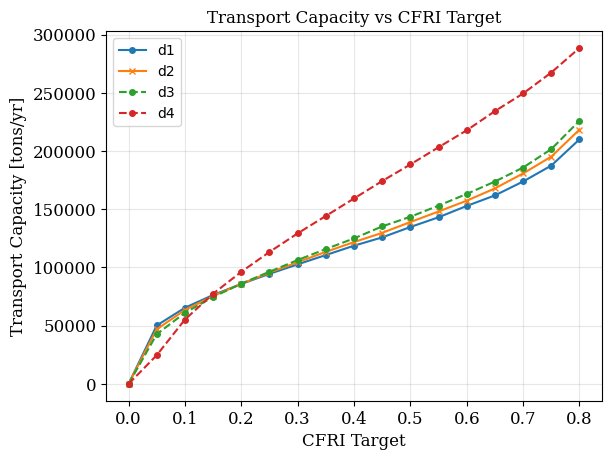

In [63]:
rc('font', **{'family': 'serif', 'serif': ['Computer Modern'], 'size': 12})
rc('text', usetex=False)
fig, ax = plt.subplots()

trade_off_esf_list = list(trade_off_dict.keys())
d1_list = [v['design'][0] * 365 for k,v in trade_off_dict.items()]
d2_list = [v['design'][1] * 365 for k,v in trade_off_dict.items()]
d3_list = [v['design'][2] * 365 for k,v in trade_off_dict.items()]
d4_list = [v['design'][3] * 365 for k,v in trade_off_dict.items()]

# plt.figure(figsize=(7,5))
ax.plot(trade_off_esf_list, d1_list, marker="o", ms=4, label='d1', linestyle='-')
ax.plot(trade_off_esf_list, d2_list, marker="x", ms=4, label='d2', linestyle='-')
ax.plot(trade_off_esf_list, d3_list, marker="o", ms=4, label='d3', linestyle='--')
ax.plot(trade_off_esf_list, d4_list, marker="o", ms=4, label='d4', linestyle='--')

ax.set_xlabel("CFRI Target")
ax.set_ylabel("Transport Capacity [tons/yr]")
plt.grid(True, alpha=0.3)
plt.rcdefaults()
plt.title("Transport Capacity vs CFRI Target")
plt.legend()
# plt.title("Design Values vs ESF Target")
# plt.savefig('NJC2025_Ex3_2_design_all.png')
plt.show()

In [64]:
import pandas as pd

In [65]:
df = pd.DataFrame({
    "ESF Target": trade_off_esf_list,
    "Cost": trade_off_cost_list,
    "d1": d1_list,
    "d2": d2_list,
    "d3": d3_list,
    "d4": d4_list,
})

In [66]:
df

,ESF Target,Cost,d1,d2,d3,d4
0,0.00,0.000000e+00,0.000000,0.000000,0.000000,0.000000
1,0.05,8.230684e+08,50227.210645,46991.214157,42709.162323,24686.098774
2,0.10,1.226542e+09,65424.526201,63486.454746,61108.829283,55288.621530
3,0.15,1.519940e+09,76370.603172,75483.042705,74672.761558,77461.494572
4,0.20,1.771061e+09,85845.787714,85994.972573,86077.796609,96293.616295
5,0.25,1.999491e+09,94559.128269,95614.566970,96379.397284,113345.014642
6,0.30,2.214432e+09,102699.210579,104500.939196,106389.879243,129296.466299
7,0.35,2.421373e+09,110698.246744,113447.182812,115859.360560,144269.779940
8,0.40,2.624114e+09,118716.685915,121836.112838,124985.226152,159284.794983
9,0.45,2.825938e+09,125858.226891,129765.162643,135296.334766,174267.865993


In [67]:
# d0_ratio_list = [(d1_list[i] - d1_list[i-1])/(esf_target_list[i] - esf_target_list[i-1]) for i in range(1, len(d1_list))]
# d1_ratio_list = [(d2_list[i] - d2_list[i-1])/(esf_target_list[i] - esf_target_list[i-1]) for i in range(1, len(d2_list))]
# d2_ratio_list = [(d3_list[i] - d3_list[i-1])/(esf_target_list[i] - esf_target_list[i-1]) for i in range(1, len(d3_list))]
# d3_ratio_list = [(d4_list[i] - d4_list[i-1])/(esf_target_list[i] - esf_target_list[i-1]) for i in range(1, len(d4_list))]

In [68]:
d_bounds

[(0, 1000), (0, 1000), (0, 1000), (0, 1000)]

In [69]:
# dv = np.array([187170.444299/365, 194715.273592/365, 201475.546842/365, 268508.739144/365])

In [70]:
dv = np.array([999, 999, 999, 999])

In [71]:
# dv = np.array([210007.778572/365, 218525.607787/365, 226028.922166/365, 288569.357628/365])

In [72]:
# dv = np.array([210007.778572/365, 218525.607787/365, 226028.922166/365, 1000])

In [73]:
dv

array([999, 999, 999, 999])

In [74]:
poly_model.predict(dv.reshape(1,-1))

array([0.35797727])

In [75]:
a = 268422.5
b = 288850.8
((b-a)/a)

0.0761050210023377